# ECG Hough Boundary Grid Preview

This notebook is intentionally small. It reuses the shared `src` Hough boundary-grid pipeline and only shows the resulting boundary lines on a compact 10-sample preview.


In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd()

from src.core import (
    EnhancementConfig,
    EnergyConfig,
    HoughBoundaryGridConfig,
    ResizeConfig,
    StandardHoughConfig,
)
from src.io import find_sample_path, load_sample_rgb_image, rgb_to_gray_unit
from src.pipelines import run_hough_boundary_grid_detection


In [2]:
import sys
from pathlib import Path


def find_project_root_for_config(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    candidates = [current, current.parent, current.parent.parent]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Could not find the project root for notebook defaults.')


PROJECT_ROOT_FOR_CONFIG = find_project_root_for_config()
if str(PROJECT_ROOT_FOR_CONFIG) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT_FOR_CONFIG))

from src.core import load_hough_boundary_notebook_defaults

HOUGH_NOTEBOOK_PROFILE = 'shared_baseline'
NOTEBOOK_DEFAULTS = load_hough_boundary_notebook_defaults(profile_name=HOUGH_NOTEBOOK_PROFILE)

# Inject all YAML profile keys as uppercase notebook variables
globals().update(NOTEBOOK_DEFAULTS)

RANDOM_SAMPLE_COUNT = 10
RANDOM_SAMPLE_SEED = 1


## Method

The method is the shared `src` pipeline:

1. resize the image
2. build the Canny edge map
3. run the standard Hough transform
4. keep all accumulator bins above the effective Hough threshold
5. find the dominant theta family and its perpendicular family
6. plot only the selected extreme lines from those two families


Available sample pairs: 29
Random sample pairs (10):
- 10140238 / 0006
- 1228736690 / 0001
- 19030958 / 0009
- 19030958 / 0006
- 10140238 / 0004
- 10140238 / 0012
- 10140238 / 0005
- 11842146 / 0010
- 11842146 / 0009
- 19030958 / 0003


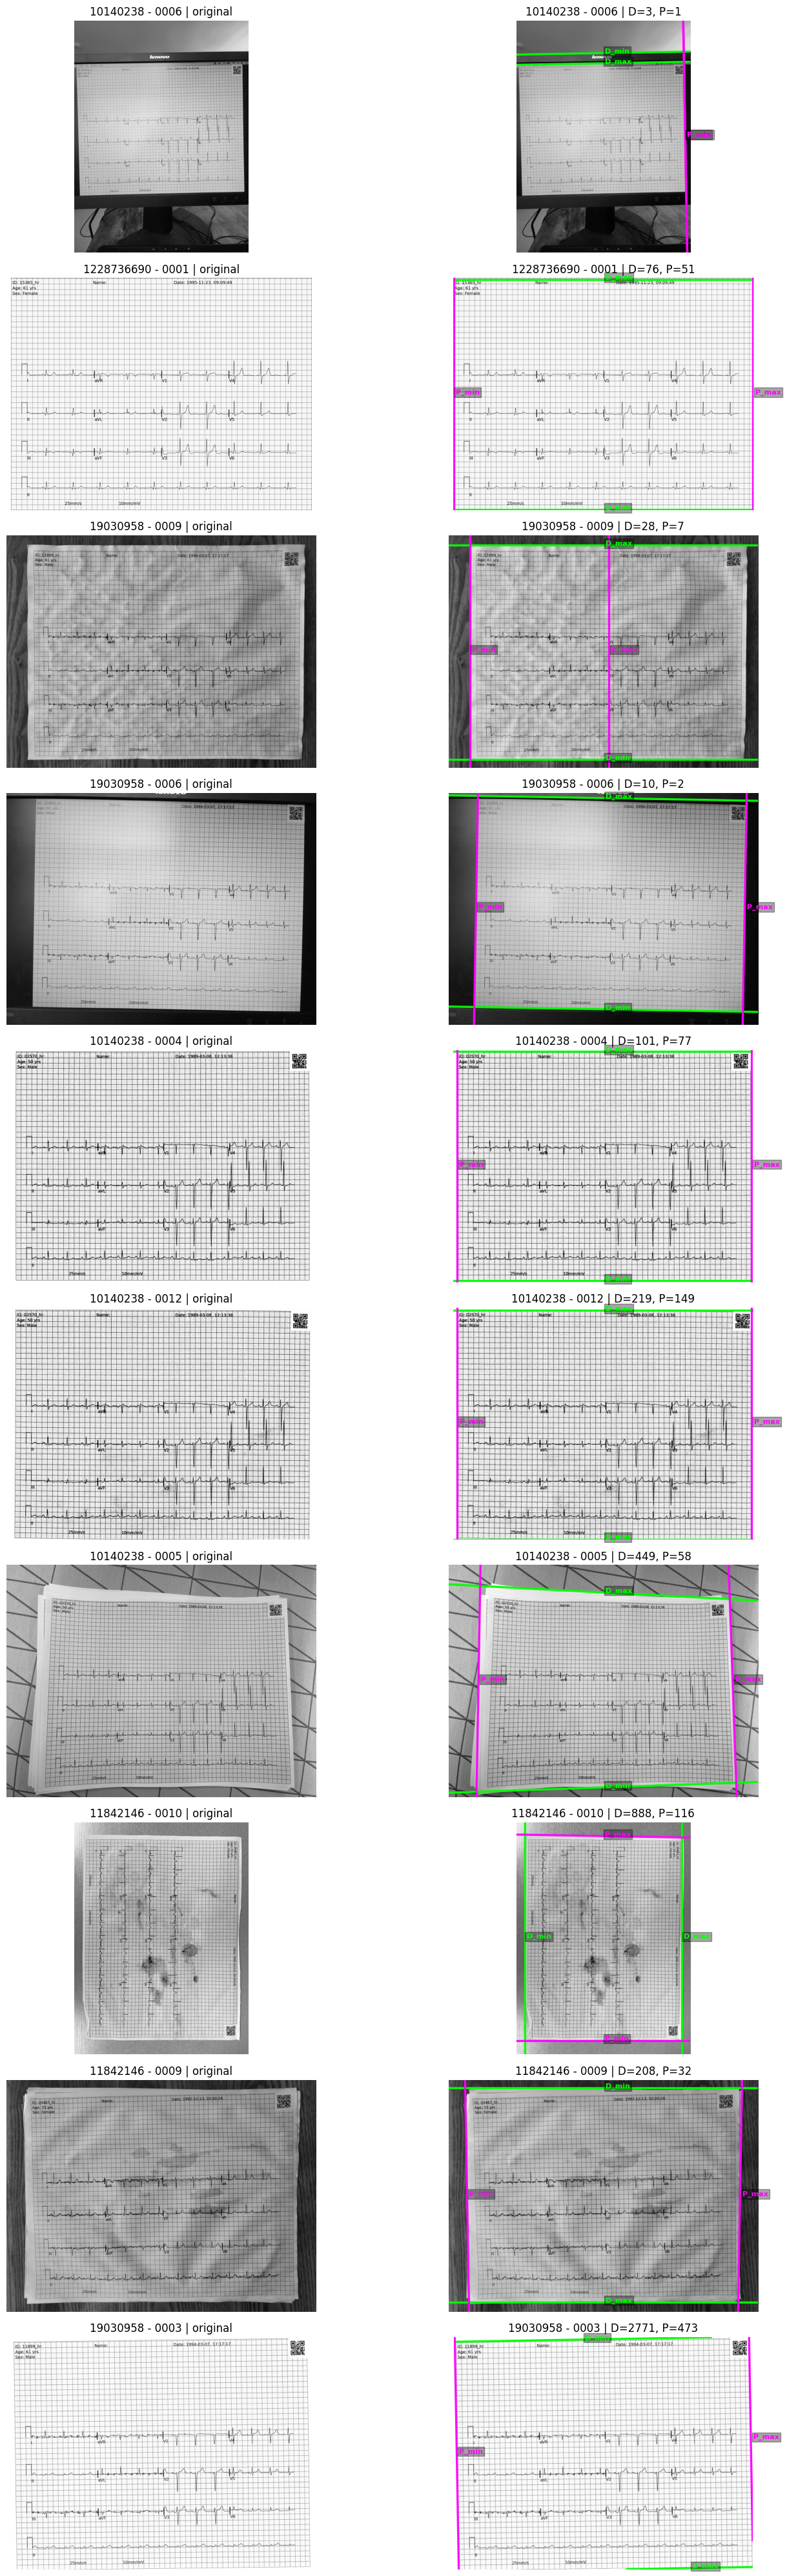

In [3]:
sample_root = find_sample_path(PROJECT_ROOT)

cfg = HoughBoundaryGridConfig(
    resize=ResizeConfig(max_dim=MAX_DIM),
    enhancement=EnhancementConfig(
        mode=ENHANCEMENT_MODE,
        unsharp_radius=UNSHARP_RADIUS,
        unsharp_amount=UNSHARP_AMOUNT,
    ),
    energy=EnergyConfig(
        mode='canny',
        gaussian_sigma=GAUSSIAN_SIGMA,
        canny_sigma=CANNY_SIGMA,
        canny_low_threshold=CANNY_LOW_THRESHOLD,
        canny_high_threshold=CANNY_HIGH_THRESHOLD,
        post_brighten_mode='none',
        post_brighten_gamma=1.0,
        outer_black_border=OUTER_BLACK_BORDER,
    ),
    standard_hough=StandardHoughConfig(
        backend=HOUGH_BACKEND,
        rho_resolution_pixels=HOUGH_RHO_RESOLUTION_PIXELS,
        theta_step_degrees=THETA_STEP_DEGREES,
        n_peaks=100  # not used by detection, only caps debug peak list,
        peak_threshold_ratio=HOUGH_PEAK_THRESHOLD_RATIO,
        min_distance=HOUGH_MIN_DISTANCE,
        min_angle=HOUGH_MIN_ANGLE,
        opencv_use_edge_values=HOUGH_OPENCV_USE_EDGE_VALUES,
        smooth_accumulator=HOUGH_SMOOTH_ACCUMULATOR,
        accumulator_gaussian_sigma_rho=HOUGH_ACCUM_SIGMA_RHO,
        accumulator_gaussian_sigma_theta=HOUGH_ACCUM_SIGMA_THETA,
    ),
    primary_theta_tolerance_deg=BOUNDARY_PRIMARY_THETA_TOLERANCE_DEG,
    perpendicular_theta_tolerance_deg=BOUNDARY_PERPENDICULAR_THETA_TOLERANCE_DEG,
)


def draw_entry(ax, entry, color, label):
    if entry is None:
        return
    (x0, y0), (x1, y1) = entry.segment
    ax.plot([x0, x1], [y0, y1], color=color, linewidth=2.4, alpha=0.95)
    xm = 0.5 * (x0 + x1)
    ym = 0.5 * (y0 + y1)
    ax.text(
        xm + 8,
        ym,
        label,
        color=color,
        fontsize=8,
        weight='bold',
        bbox={'facecolor': 'black', 'alpha': 0.35, 'pad': 1.5},
    )


def plot_sample_pair(left_ax, right_ax, ecg_id, scan_type):
    rgb_img, image_path = load_sample_rgb_image(sample_root, ecg_id, scan_type)
    gray_img = rgb_to_gray_unit(rgb_img)
    result = run_hough_boundary_grid_detection(gray_img, cfg)

    left_ax.imshow(gray_img, cmap='gray')
    left_ax.set_title(f'{ecg_id} - {scan_type} | original')
    left_ax.axis('off')

    right_ax.imshow(result.energy.resized_gray, cmap='gray')
    right_ax.axis('off')

    dominant_count = len(result.dominant_family.entries) if result.dominant_family else 0
    perpendicular_count = len(result.perpendicular_family.entries) if result.perpendicular_family else 0
    right_ax.set_title(
        f'{ecg_id} - {scan_type} | D={dominant_count}, P={perpendicular_count}'
    )

    if result.dominant_family is not None:
        draw_entry(right_ax, result.dominant_family.min_entry, 'lime', 'D_min')
        draw_entry(right_ax, result.dominant_family.max_entry, 'lime', 'D_max')
    if result.perpendicular_family is not None:
        draw_entry(right_ax, result.perpendicular_family.min_entry, 'magenta', 'P_min')
        draw_entry(right_ax, result.perpendicular_family.max_entry, 'magenta', 'P_max')

    if result.dominant_family is None and result.perpendicular_family is None:
        right_ax.text(0.5, 0.5, 'No boundary families found', color='white', ha='center', va='center', transform=right_ax.transAxes)


def collect_sample_pairs(sample_root):
    sample_pairs = []
    for folder in sorted(sample_root.iterdir()):
        if not folder.is_dir():
            continue
        ecg_id = folder.name
        png_paths = sorted(path for path in folder.glob(f'{ecg_id}-*.png') if path.is_file())
        if not png_paths:
            continue
        for png_path in png_paths:
            scan_type = png_path.stem.rsplit('-', maxsplit=1)[-1]
            sample_pairs.append((ecg_id, scan_type))
    return sample_pairs


all_sample_pairs = collect_sample_pairs(sample_root)
rng = random.Random(RANDOM_SAMPLE_SEED)
sample_count = min(RANDOM_SAMPLE_COUNT, len(all_sample_pairs))
SAMPLE_PAIRS = rng.sample(all_sample_pairs, sample_count)

print(f'Available sample pairs: {len(all_sample_pairs)}')
print(f'Random sample pairs ({sample_count}):')
for ecg_id, scan_type in SAMPLE_PAIRS:
    print(f'- {ecg_id} / {scan_type}')

fig, axes = plt.subplots(sample_count, 2, figsize=(16, 4 * sample_count))
if sample_count == 1:
    axes = np.array([axes])
for row_idx, (ecg_id, scan_type) in enumerate(SAMPLE_PAIRS):
    plot_sample_pair(axes[row_idx, 0], axes[row_idx, 1], ecg_id, scan_type)

plt.tight_layout()
plt.show()
